In [1]:
#
# Import required libraries
#
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import tifffile
import torch

print("PyTorch version: " + str(torch.__version__))
!python --version

PyTorch version: 2.9.0+cu126
Python 3.12.12


In [2]:
#
# Mount my Google Drive and move to working dir
#
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/'Colab Notebooks'/podosome-segmentation
%pwd

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/podosome-segmentation


'/content/drive/MyDrive/Colab Notebooks/podosome-segmentation'

In [3]:
#
# Initial settings
#
dir_save = Path('results')
dir_save.mkdir(parents=True, exist_ok=True)

dir_data = Path('data')
dir_data.mkdir(parents=True, exist_ok=True)

Text(0.5, 1.0, 'Image')

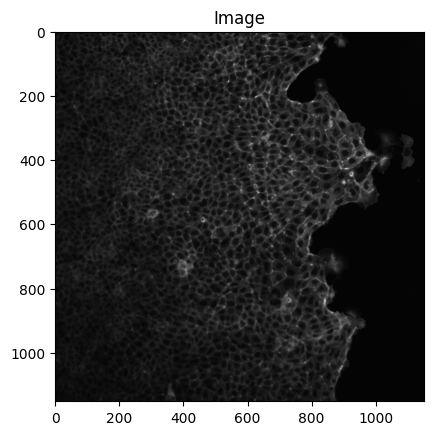

In [4]:
#
# Load input image
#
input_path = dir_data / 'imgs.tif'
mov = np.array(tifffile.imread(input_path), dtype='float32')

plt.imshow(mov[0, :, :], cmap='gray')
plt.title('Image')

In [5]:
#
# Load trained weights of segmentation model
#
from models import NarrowUNet

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Chosen device: " + str(device))
model = NarrowUNet(n_channels=3, n_classes=1, bilinear=True)
model.to(device)

model.load_state_dict(torch.load('weight.pt'))

Chosen device: cuda


<All keys matched successfully>

(1152, 1152)


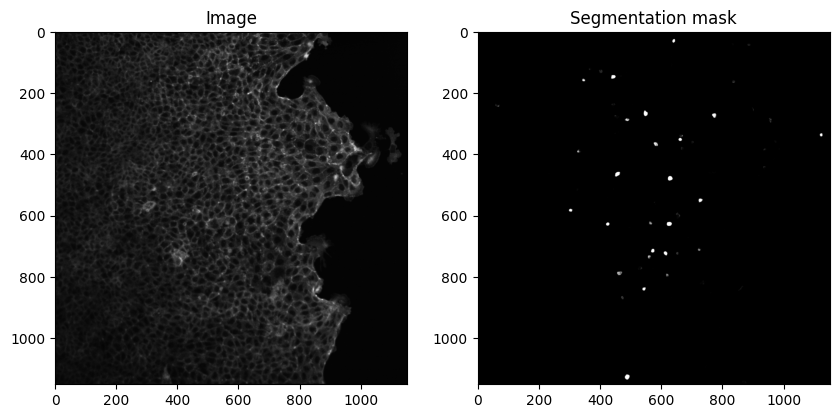

In [6]:
#
# Apply segmentation model
#
def predict_snapshot(net, img):
    net.eval()
    img = img / np.max(img)
    img = torch.tensor(img[np.newaxis, :, :, :].copy(), dtype=torch.float32)
    with torch.no_grad():
        input = img.to(device)
        test_pred = torch.sigmoid(net(input))
    test_pred = test_pred.detach().cpu().numpy()
    return np.squeeze(test_pred)

label = predict_snapshot(model, mov[0:3, :, :])
print(label.shape)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
ax[0].imshow(mov[1, :, :], cmap='gray')
ax[1].imshow(label, cmap='gray')

ax[0].set_title('Image')
ax[1].set_title('Segmentation mask')

tifffile.imwrite(dir_save / 'result.tif', label)